In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Customer Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#replacing blanks with 0 as tenure is 0 and no total charges are recorded 

In [3]:
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [7]:
df["customerID"].duplicated().sum()

0

In [8]:
df.duplicated().sum()

0

In [9]:
col_list = df.columns.tolist()
print(col_list)
for col in col_list:
    print(f"{col}: {df[col].value_counts()} unique values")

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
customerID: customerID
7590-VHVEG    1
3791-LGQCY    1
6008-NAIXK    1
5956-YHHRX    1
5365-LLFYV    1
             ..
9796-MVYXX    1
2637-FKFSY    1
1552-AAGRX    1
4304-TSPVK    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64 unique values
gender: gender
Male      3555
Female    3488
Name: count, dtype: int64 unique values
SeniorCitizen: SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64 unique values
Partner: Partner
No     3641
Yes    3402
Name: count, dtype: int64 unique values
Dependents: Dependents
No     4933
Yes    2110
Name: count, dtype: int64 unique values
tenure: tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28    

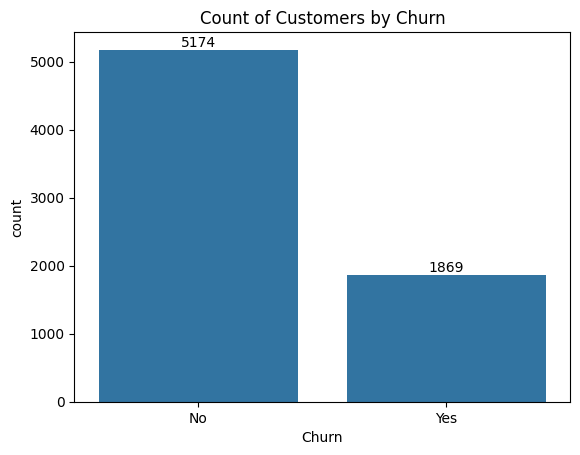

In [10]:
ax = sns.countplot(x = 'Churn', data = df)

ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Churn")
plt.show()

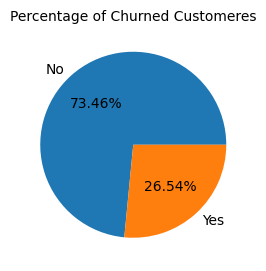

In [11]:
plt.figure(figsize = (3,4))
gb = df.groupby("Churn").agg({'Churn':"count"})
plt.pie(gb['Churn'], labels = gb.index, autopct = "%1.2f%%")
plt.title("Percentage of Churned Customeres", fontsize = 10)
plt.show()

#from the given pie chart we can conclude that 26.54% of our customers have churned out. 
#now let's explore the reason behind it

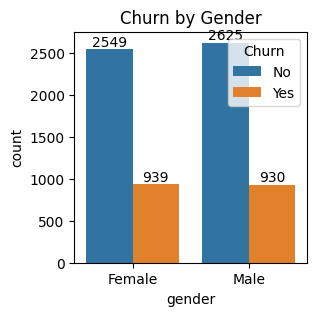

In [12]:
plt.figure(figsize = (3,3))
ax = sns.countplot(x = "gender", data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churn by Gender")
plt.show()

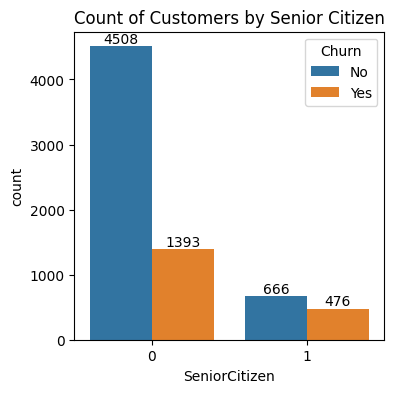

In [13]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x = "SeniorCitizen", data = df , hue = "Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Count of Customers by Senior Citizen")
plt.show()

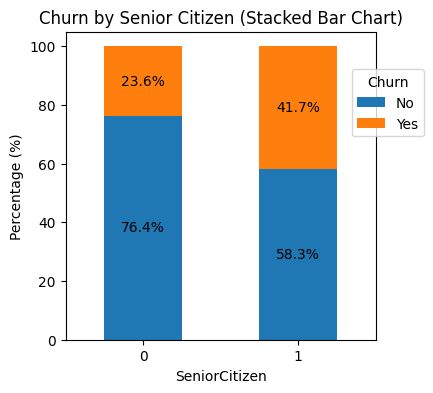

In [14]:
total_counts = df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack() * 100

# Plot
fig, ax = plt.subplots(figsize=(4, 4))  # Adjust figsize for better visualization

# Plot the bars
total_counts.plot(kind='bar', stacked=True, ax=ax, color=['#1f77b4', '#ff7f0e'])  # Customize colors if desired

# Add percentage labels on the bars
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, y + height / 2, f'{height:.1f}%', ha='center', va='center')

plt.title('Churn by Senior Citizen (Stacked Bar Chart)')
plt.xlabel('SeniorCitizen')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Churn', bbox_to_anchor = (0.9,0.9))  # Customize legend location

plt.show()

#comparative a greater pecentage of people in senior citizen category have churned

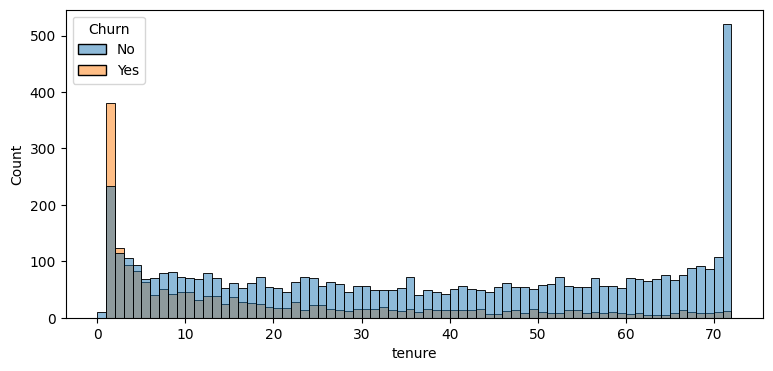

In [15]:
plt.figure(figsize = (9,4))
sns.histplot(x = "tenure", data = df, bins = 72, hue = "Churn")
plt.show()

#people who have used our services for a long time have stayed and people who have used our sevices 
#1 or 2 months  have churned

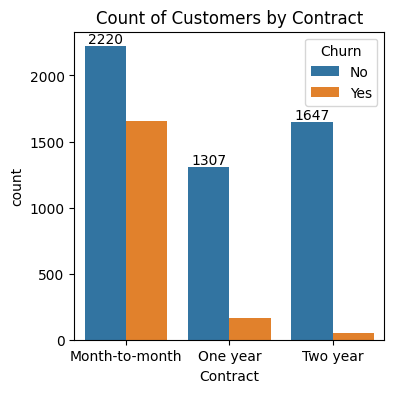

In [16]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x = "Contract", data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Contract")
plt.show()

In [17]:
#people who have month to month contract are likely to churn then from those who have 1 or 2 years or contract. 

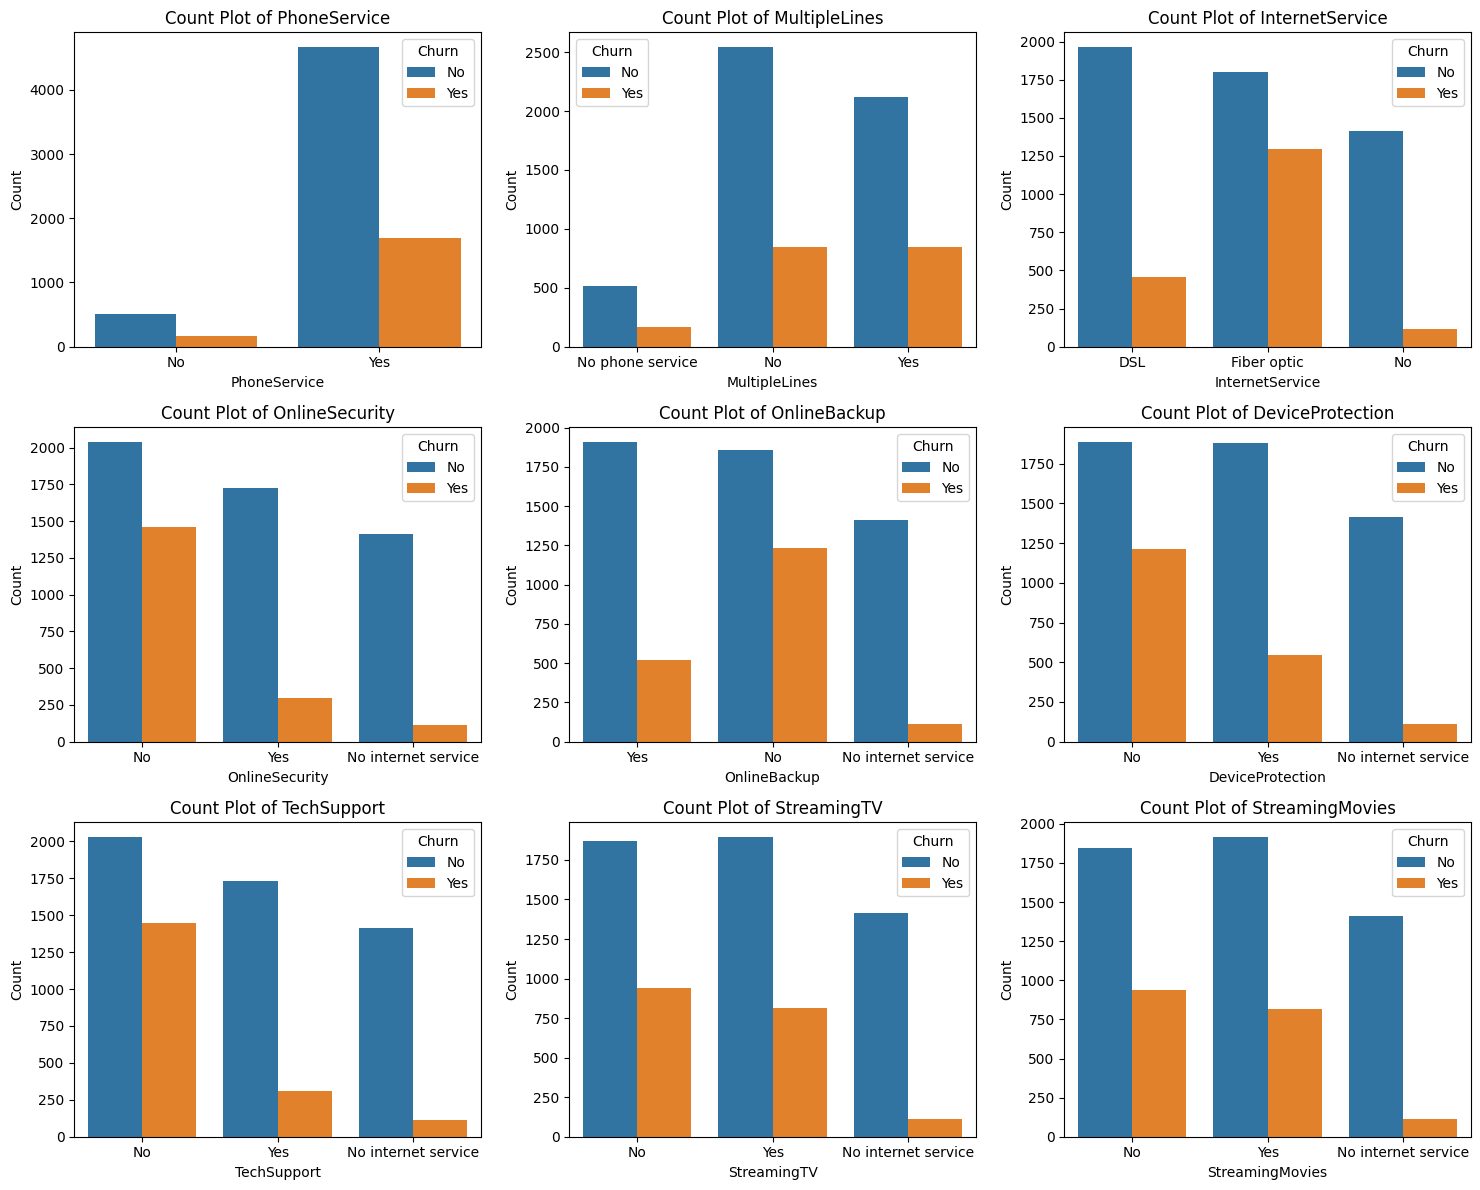

In [18]:
columns = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
           'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Number of columns for the subplot grid (you can change this)
n_cols = 3
n_rows = (len(columns) + n_cols - 1) // n_cols  # Calculate number of rows needed

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))  # Adjust figsize as needed

# Flatten the axes array for easy iteration (handles both 1D and 2D arrays)
axes = axes.flatten()

# Iterate over columns and plot count plots
for i, col in enumerate(columns):
    sns.countplot(x=col, data=df, ax=axes[i], hue = df["Churn"])
    axes[i].set_title(f'Count Plot of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Remove empty subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#The majority of customers who do not churn tend to have services like PhoneService, InternetService (particularly DSL), and OnlineSecurity enabled. For services like OnlineBackup, TechSupport, and StreamingTV, churn rates are noticeably higher when these services are not used or are unavailable. 

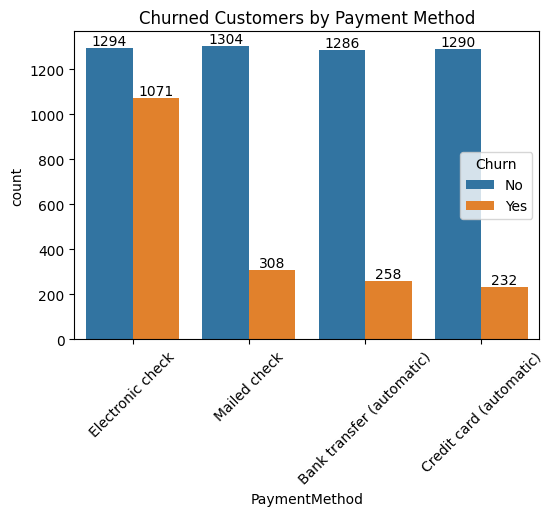

In [19]:
plt.figure(figsize = (6,4))
ax = sns.countplot(x = "PaymentMethod", data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churned Customers by Payment Method")
plt.xticks(rotation = 45)
plt.show()

#customer is likely to churn when he is using electronic check as a payment method. 

In [20]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)
# SMOTE — creates synthetic minority-class samples to fix class imbalance
from imblearn.over_sampling import SMOTE

In [22]:
'''CELL: Create Engineered Features
PURPOSE : Derive 4 business-meaningful features from existing raw columns.
          These new features often carry more predictive signal than any
          individual raw column because they encode domain knowledge.

FEATURE DETAILS:
  1. tenure_group  — Bucket continuous tenure into 6 equal-width groups.
     Why: Churn risk is highest in months 0–12, drops steeply after 24 months.
     A linear tenure value doesn't capture this non-linearity well.

  2. ChargesPerMonth — Average monthly spend.
     Why: TotalCharges alone is confounded by tenure (long-tenure customers
     have high totals even if they pay little per month). This normalises it.
     (tenure+1) in denominator prevents division-by-zero for new customers.

  3. NumServices — Count of active add-on services (out of 8 possible).
     Why: Each additional service increases switching cost. A customer
     with 6 active services has to cancel 6 things to leave — far more
     friction than a single-service customer.

  4. HighRiskFlag — 1 if customer is Month-to-month + Fiber Optic + E-check.
     Why: This combination represents the highest-churn profile. Flagging
     it explicitly makes it directly actionable by the retention team.

OUTPUT  : df gains 4 new columns. Head table confirms values are correct. '''

# 1. Tenure Group
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=["0-12m", "13-24m", "25-36m", "37-48m", "49-60m", "61-72m"],
    include_lowest=True
)

# 2. Charges Per Month (average, tenure-normalised)
df["ChargesPerMonth"] = (df["TotalCharges"] / (df["tenure"] + 1)).round(2)

# 3. Number of Active Services (count of "Yes" across 8 service columns)
service_flags = [
    "PhoneService", "MultipleLines", "OnlineSecurity",
    "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies"
]
df["NumServices"] = df[service_flags].apply(
    lambda col: col.map({"Yes": 1}).fillna(0)
).sum(axis=1).astype(int)

# 4. High Risk Flag (compound business rule)
df["HighRiskFlag"] = (
    (df["Contract"] == "Month-to-month") &
    (df["InternetService"] == "Fiber optic") &
    (df["PaymentMethod"] == "Electronic check")
).astype(int)

print("New features created:")
print(df[["tenure", "tenure_group", "TotalCharges", "ChargesPerMonth",
          "NumServices", "HighRiskFlag", "Churn"]].head(10).to_string(index=False))


New features created:
 tenure tenure_group  TotalCharges  ChargesPerMonth  NumServices  HighRiskFlag Churn
      1        0-12m         29.85            14.92            1             0    No
     34       25-36m       1889.50            53.99            3             0    No
      2        0-12m        108.15            36.05            3             0   Yes
     45       37-48m       1840.75            40.02            3             0    No
      2        0-12m        151.65            50.55            1             1   Yes
      8        0-12m        820.50            91.17            5             1   Yes
     22       13-24m       1949.40            84.76            4             0    No
     10        0-12m        301.90            27.45            1             0    No
     28       25-36m       3046.05           105.04            6             1   Yes
     62       61-72m       3487.95            55.36            3             0    No


C:\Users\Himanshu\AppData\Local\Temp\ipykernel_10564\2396262316.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df.groupby([col, "Churn"]).size().unstack(fill_value=0)


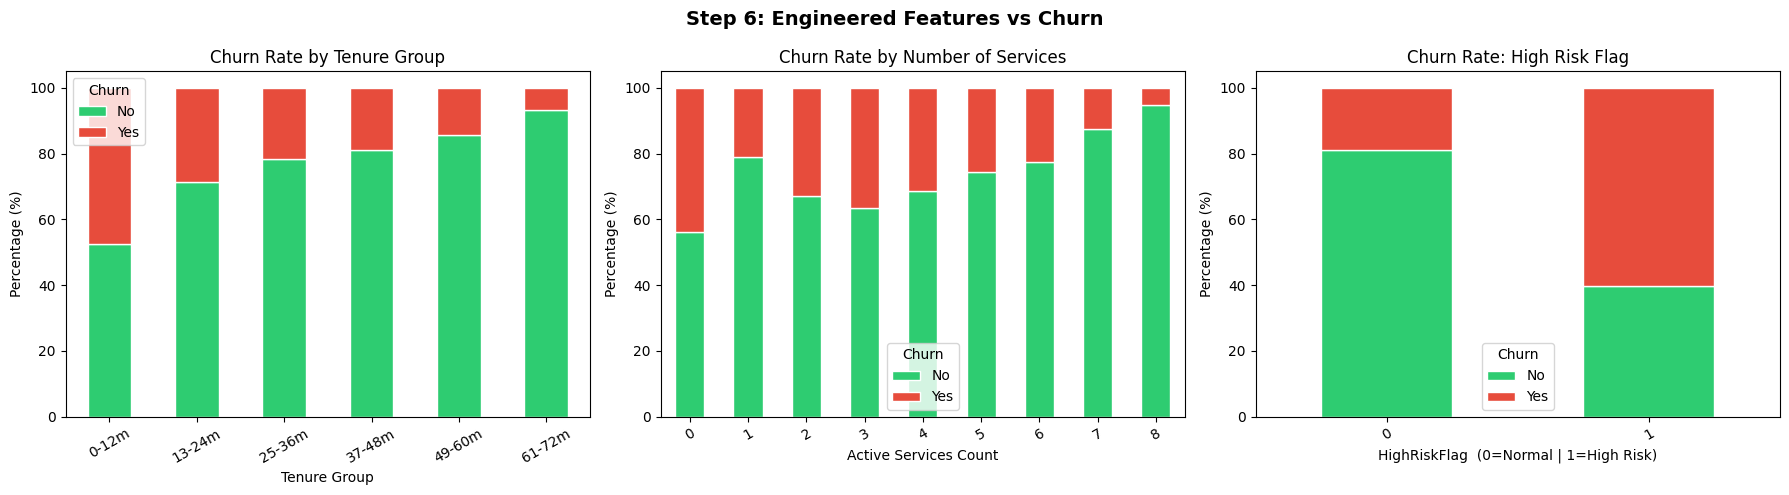

In [24]:
'''CELL: Validate Engineered Features vs Churn
PURPOSE : Verify that the new features actually carry predictive signal.
          If an engineered feature has no relationship with Churn, it was
          not worth creating (and may add noise to models).

OUTPUT  : 3 stacked bar charts (tenure_group, NumServices, HighRiskFlag)
          showing churn % within each category.

CHART ANALYSIS:
  - tenure_group:  0-12m bucket shows ~50% churn rate → confirms early
    tenure is the highest-risk window. Rate drops below 5% for 61-72m.
  - NumServices: Customers with 0-1 services churn at ~50%+. Those with
    5+ services churn at <15%. Clear inverse relationship confirmed.
  - HighRiskFlag=1: ~65%+ churn rate vs ~24% for non-flagged customers.
    This 1-bit flag is highly actionable — it targets the worst cases.'''

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def stacked_churn_bar(col, ax, title, xlabel):
    grp = df.groupby([col, "Churn"]).size().unstack(fill_value=0)
    pct = grp.div(grp.sum(axis=1), axis=0) * 100
    pct.plot(kind="bar", stacked=True, ax=ax,
             color=["#2ecc71", "#e74c3c"], edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Percentage (%)")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(title="Churn")

stacked_churn_bar("tenure_group",  axes[0],
                  "Churn Rate by Tenure Group", "Tenure Group")
stacked_churn_bar("NumServices",   axes[1],
                  "Churn Rate by Number of Services", "Active Services Count")
stacked_churn_bar("HighRiskFlag",  axes[2],
                  "Churn Rate: High Risk Flag",
                  "HighRiskFlag  (0=Normal | 1=High Risk)")

plt.suptitle("Step 6: Engineered Features vs Churn", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [27]:
'''Predictive Modelling & Evaluation
ML Pipeline:
1. Encode features (Label Encoding + One-Hot Encoding)
2. Scale numeric features (StandardScaler)
3. Stratified 80/20 Train-Test Split
4. Apply SMOTE only to training data (to fix class imbalance without data leakage)
5. Train 3 models: Logistic Regression, Random Forest, Gradient Boosting
6. Evaluate: Accuracy, Precision, Recall, F1, ROC-AUC
7. Confusion matrices + ROC curves + Feature Importances

Why Recall matters most here:Missing a churner (False Negative) = lost revenue. Falsely flagging a loyal customer (False Positive) = a 
wasted discount offer. In most churn use cases, the cost of FN >> FP, so we optimise for Recall.
'''

'Predictive Modelling & Evaluation\nML Pipeline:\n1. Encode features (Label Encoding + One-Hot Encoding)\n2. Scale numeric features (StandardScaler)\n3. Stratified 80/20 Train-Test Split\n4. Apply SMOTE only to training data (to fix class imbalance without data leakage)\n5. Train 3 models: Logistic Regression, Random Forest, Gradient Boosting\n6. Evaluate: Accuracy, Precision, Recall, F1, ROC-AUC\n7. Confusion matrices + ROC curves + Feature Importances\n\nWhy Recall matters most here:Missing a churner (False Negative) = lost revenue. Falsely flagging a loyal customer (False Positive) = a \nwasted discount offer. In most churn use cases, the cost of FN >> FP, so we optimise for Recall.\n'

In [28]:
'''
PURPOSE : Convert all categorical features to numeric format for sklearn.

ENCODING STRATEGY:
  - Binary Yes/No columns      → LabelEncoder (0/1) — avoids dummy explosion
  - Multi-class columns        → pd.get_dummies with drop_first=True
                                 (removes one dummy per group to avoid the
                                  "dummy variable trap" / perfect multicollinearity)
  - customerID                 → Dropped (unique ID, not a feature)

OUTPUT  : df_ml — fully numeric DataFrame ready for sklearn.'''

df_ml = df.copy()
df_ml.drop("customerID", axis=1, inplace=True)       # Drop identifier column

# Binary columns → 0 / 1
binary_cols = [
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "PaperlessBilling", "Churn"
]
le_ml = LabelEncoder()
for col in binary_cols:
    df_ml[col] = le_ml.fit_transform(df_ml[col].astype(str))

# Multi-class categoricals → One-Hot Encoding
multi_cat_cols = [
    "MultipleLines", "InternetService", "OnlineSecurity",
    "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies", "Contract",
    "PaymentMethod", "tenure_group"
]
df_ml = pd.get_dummies(df_ml, columns=multi_cat_cols, drop_first=True)

print(f"ML-ready DataFrame shape: {df_ml.shape}")
print(f"Total features for modelling: {df_ml.shape[1] - 1}")


ML-ready DataFrame shape: (7043, 39)
Total features for modelling: 38


In [29]:
'''
Train-Test Split + Feature Scaling + SMOTE

STEPS:
  1. Separate features (X) from target (y = Churn)
  2. StandardScaler: centres and scales features to mean=0, std=1.
     Why: Logistic Regression is sensitive to feature scale. Trees are not,
     but we scale for all models for a fair comparison.
  3. Stratified split: preserves churn ratio in both train and test.
     Why: Without stratification, by random chance the test set might have
     a very different churn rate, making evaluation unreliable.
  4. SMOTE on TRAINING DATA ONLY:
     Creates synthetic minority (churn=1) samples by interpolating between
     real churners in feature space. Applied only to train — never to test.
     Applying SMOTE to the test set would be data leakage.

OUTPUT  : Sizes of all splits before and after SMOTE.
'''

X = df_ml.drop("Churn", axis=1)     # Feature matrix (all columns except target)
y = df_ml["Churn"]                   # Target vector (0=No Churn, 1=Churn)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train size : {X_train.shape[0]:,} samples")
print(f"Test size  : {X_test.shape[0]:,} samples")
print(f"Train churn rate : {y_train.mean():.3f}  |  Test churn rate : {y_test.mean():.3f}")

# SMOTE — balance training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"  Training size  : {X_train_res.shape[0]:,}")
print(f"  Churn=0 count  : {(y_train_res == 0).sum():,}  |  Churn=1 count : {(y_train_res == 1).sum():,}")
print(f"  Balanced ratio : {y_train_res.mean():.3f}")


Train size : 5,634 samples
Test size  : 1,409 samples
Train churn rate : 0.265  |  Test churn rate : 0.265

After SMOTE:
  Training size  : 8,278
  Churn=0 count  : 4,139  |  Churn=1 count : 4,139
  Balanced ratio : 0.500


In [30]:
'''
 Train 3 Models & Print Performance
PURPOSE : Train Logistic Regression, Random Forest, and Gradient Boosting.
          Print full classification report for each model on the test set.

WHY THESE 3 MODELS:
  - Logistic Regression : Interpretable linear baseline. Good for linearly
    separable patterns. Coefficients are directly interpretable.
  - Random Forest       : Ensemble of decision trees. Handles non-linearity
    and feature interactions. Robust to outliers and noisy features.
  - Gradient Boosting   : Sequential tree ensemble; often best performer.
    Builds each tree to correct the errors of the previous one.

OUTPUT  : Classification report per model + summary comparison table.

METRICS EXPLAINED:
  Precision = of all customers we predicted would churn, what % actually did?
              (measures false alarm rate)
  Recall    = of all customers who actually churned, what % did we catch?
              (measures missed churner rate — most important here)
  F1        = harmonic mean of Precision and Recall (balance metric)
  ROC-AUC   = overall ranking ability; 0.5 = random, 1.0 = perfect
'''

models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting"   : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results  = {}    # Metric scores for comparison table
trained  = {}    # Fitted models + predictions for plotting

for name, model in models.items():
    model.fit(X_train_res, y_train_res)            # Train on SMOTE-balanced data
    y_pred  = model.predict(X_test)                # Class prediction on real test data
    y_proba = model.predict_proba(X_test)[:, 1]    # Churn probability (for ROC-AUC)

    results[name] = {
        "Accuracy"  : accuracy_score(y_test, y_pred),
        "Precision" : precision_score(y_test, y_pred),
        "Recall"    : recall_score(y_test, y_pred),
        "F1"        : f1_score(y_test, y_pred),
        "ROC-AUC"   : roc_auc_score(y_test, y_proba)
    }
    trained[name] = (model, y_pred, y_proba)

    print(f"\n{'='*60}")
    print(f"  {name}")
    print("="*60)
    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

# Summary comparison table
results_df = pd.DataFrame(results).T.round(4)
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(results_df.to_string())
print("\n→ Best model for Recall (catching churners) and ROC-AUC: see table above.")



  Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409


  Random Forest
              precision    recall  f1-score   support

    No Churn       0.85      0.85      0.85      1035
       Churn       0.58      0.58      0.58       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409


  Gradient Boosting
              precision    recall  f1-score   support

    No Churn       0.87      0.82      0.85      1035
       Churn       0.57      0.67      0.62       374

    accuracy                           0.78      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg 

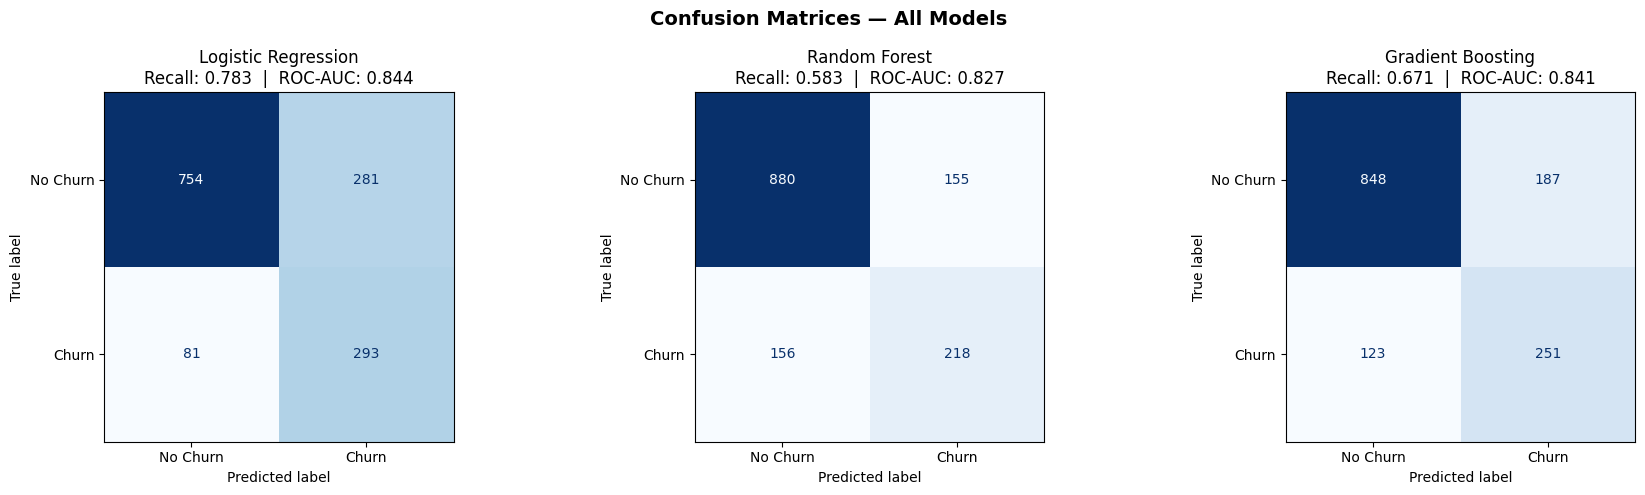

In [32]:
'''
CELL: Confusion Matrices — All Models
PURPOSE : Visualise the 4-quadrant prediction outcome breakdown.

CONFUSION MATRIX LAYOUT:
             Predicted: No Churn  |  Predicted: Churn
  Actual: No Churn    TN           |      FP
  Actual: Churn       FN           |      TP

KEY CELL:
  FN (bottom-left) = Actual churners we MISSED → most costly error.
  We want FN to be as small as possible → maximise Recall.

OUTPUT  : 1*3 grid of confusion matrices with Recall and AUC in subtitle.

CHART ANALYSIS:
  - Logistic Regression: moderate FN, interpretable
  - Random Forest: lower FN than LR, handles feature interactions
  - Gradient Boosting: typically lowest FN — best churn catcher
'''

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, (model, y_pred, _)) in zip(axes, trained.items()):
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=["No Churn", "Churn"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(
        f"{name}\n"
        f"Recall: {results[name]['Recall']:.3f}  |  ROC-AUC: {results[name]['ROC-AUC']:.3f}"
    )

plt.suptitle("Confusion Matrices — All Models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


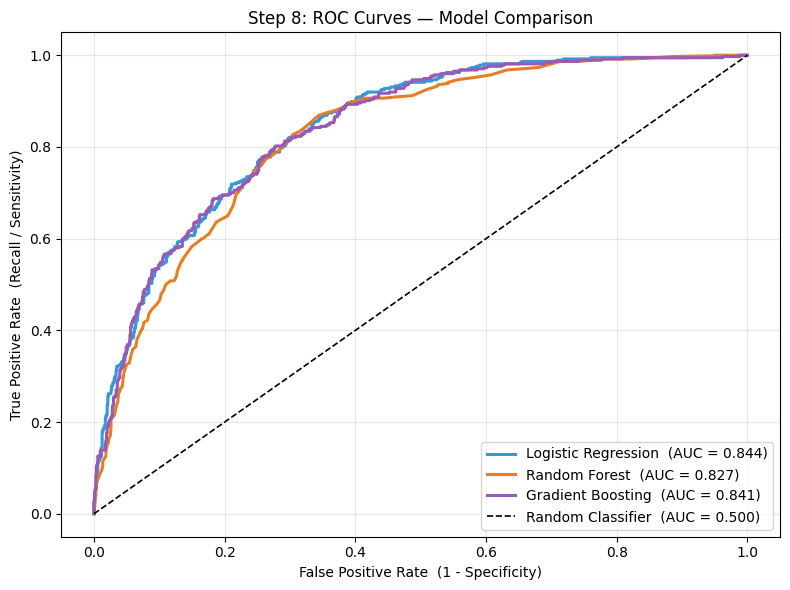

In [33]:
'''
CELL: ROC Curves — All Models
PURPOSE : ROC (Receiver Operating Characteristic) plots True Positive Rate
          (Recall) vs False Positive Rate at every possible decision threshold.
          AUC (Area Under Curve) summarises the curve as a single number.

INTERPRETING THE CHART:
  - Diagonal dashed line = random classifier (AUC = 0.50, useless baseline)
  - A curve hugging the top-left corner = excellent discrimination
  - AUC > 0.80 is considered good for a churn model
  - AUC > 0.85 is excellent

WHY ROC + CONFUSION MATRIX TOGETHER:
  ROC shows performance across all thresholds (gives the full picture).
  Confusion matrix shows performance at the default 0.5 threshold (actionable).
  Together they give both the strategic and operational view.

OUTPUT  : Overlaid ROC curves for all 3 models on a single chart.
'''

plt.figure(figsize=(8, 6))
colors_roc = ["#3498db", "#e67e22", "#9b59b6"]

for (name, (model, _, y_proba)), color in zip(trained.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = results[name]["ROC-AUC"]
    plt.plot(fpr, tpr, label=f"{name}  (AUC = {auc:.3f})", color=color, lw=2.2)

# Random baseline
plt.plot([0, 1], [0, 1], "k--", lw=1.2, label="Random Classifier  (AUC = 0.500)")

plt.xlabel("False Positive Rate  (1 - Specificity)")
plt.ylabel("True Positive Rate  (Recall / Sensitivity)")
plt.title("Step 8: ROC Curves — Model Comparison")
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
Business Insights & Actionable Recommendations



| # | Finding | Evidence | Recommended Action | Priority |
|---|---------|----------|--------------------|----------|
| 1 | Month-to-month contracts → ~42% churn | Contract vs Churn plot | Discount/upgrade incentives to annual plans |  High |
| 2 | Senior citizens churn at 2× non-senior rate | SeniorCitizen stacked bar | Dedicated support programme, simplified pricing |  High |
| 3 | Fiber Optic + high charges → highest churn | MonthlyCharges boxplot | Quality audit; price-match guarantee |  High |
| 4 | 0–12 month tenure = 50%+ churn | Tenure group chart | Redesign onboarding; loyalty reward at month 3 |  High |
| 5 | Electronic check payers churn most | PaymentMethod countplot | Incentivise auto-pay (bank transfer / credit card) |  Medium |
| 6 | Each additional service reduces churn | NumServices feature | Cross-sell bundles to single-service customers |  Medium |
| 7 | HighRiskFlag captures ~65% churn probability | HighRiskFlag validation chart | Weekly retention outreach to all flagged customers |  High |


In [37]:
'''  1. cleaned_telco_data.csv       — Clean, feature-enriched dataset.
     Use: load into BI tools (Tableau, Power BI) or share with data team.

  2. model_performance_summary.csv — Metric comparison across all models.
     Use: share with leadership as model validation evidence. Compare with
     future runs to detect model drift.
'''


# 1. Cleaned and enriched dataset
df.to_csv("cleaned_telco_data.csv", index=False)
print("Exported: cleaned_telco_data.csv")

# 2. Model performance summary
results_df.to_csv("model_performance_summary.csv")
print("Exported: model_performance_summary.csv")


Exported: cleaned_telco_data.csv
Exported: model_performance_summary.csv


In [44]:
import pickle
import joblib
log_reg_model = trained["Logistic Regression"][0]
feature_names = X.columns.tolist()

joblib.dump(log_reg_model, "logistic_regression_model.pkl")
joblib.dump(scaler, "logistic_regression_scaler.pkl")
joblib.dump(feature_names, "feature_names.pkl") 


['feature_names.pkl']

In [49]:
import pandas as pd
import numpy as np
import joblib

# Load saved artifacts
loaded_model = joblib.load("logistic_regression_model.pkl")
loaded_scaler = joblib.load("logistic_regression_scaler.pkl")
loaded_features = joblib.load("feature_names.pkl")

# Take 10 customers from ORIGINAL RAW DATA
sample_raw = X.iloc[:10].copy()

print("Sample Shape:", sample_raw.shape)

# Original pipeline prediction
sample_scaled_original = scaler.transform(sample_raw)

original_pred = trained["Logistic Regression"][0].predict(sample_scaled_original)
original_prob = trained["Logistic Regression"][0].predict_proba(sample_scaled_original)[:,1]

# Loaded pipeline prediction
sample_scaled_loaded = loaded_scaler.transform(sample_raw)

loaded_pred = loaded_model.predict(sample_scaled_loaded)
loaded_prob = loaded_model.predict_proba(sample_scaled_loaded)[:,1]

# Compare
results = pd.DataFrame({
    "Original_Pred": original_pred,
    "Loaded_Pred": loaded_pred,
    "Original_Prob": np.round(original_prob,4),
    "Loaded_Prob": np.round(loaded_prob,4),
    "Match": original_pred == loaded_pred
})

print(results)

print("\nPrediction Match:",
      np.array_equal(original_pred, loaded_pred))

print("Probability Match:",
      np.allclose(original_prob, loaded_prob))

Sample Shape: (10, 38)
   Original_Pred  Loaded_Pred  Original_Prob  Loaded_Prob  Match
0              1            1         0.8381       0.8381   True
1              0            0         0.0585       0.0585   True
2              1            1         0.5962       0.5962   True
3              0            0         0.0735       0.0735   True
4              1            1         0.8891       0.8891   True
5              1            1         0.9118       0.9118   True
6              1            1         0.6004       0.6004   True
7              0            0         0.4299       0.4299   True
8              1            1         0.7546       0.7546   True
9              0            0         0.0379       0.0379   True

Prediction Match: True
Probability Match: True
